***Homework 2 (model 2, lesson 2)***

In [1]:
import pandas as pd
import numpy as np
url = " https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv"
try:
    df = pd.read_csv(url, encoding='latin-1')
    print(f"Loaded from URL: {df.shape[0]} rows, {df.shape[1]} columns")
except Exception as e:
    print(f"URL failed ({e}). Use Option A: upload the CSV manually.")
    # Fallback: upload manually
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename, encoding='latin-1')
    print(f"Loaded from upload: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded from URL: 10800 rows, 21 columns


In [2]:
# shows rows and columns
print("Shape:", df.shape)

Shape: (10800, 21)


In [3]:
df.shape

(10800, 21)

In [4]:
# non-null counts - not filled columns
# df.info() - shows non-null count and Dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10800 non-null  object 
 1   Order ID       10800 non-null  object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quanti

In [5]:
#df.describe() -  for summary statistics of numerical columns (shows count, mean, std, min, max ... of data)
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55245.233297,229.858001,3.789574,0.156203,28.656896
std,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
#Check for missing values
print(df.isnull().sum())

Row ID             0
Order ID           0
Order Date       806
Ship Date        806
Ship Mode        806
Customer ID      806
Customer Name    806
Segment          806
Country          806
City             806
State            806
Postal Code      817
Region           806
Product ID       806
Category         806
Sub-Category     806
Product Name     806
Sales            806
Quantity         806
Discount         806
Profit           806
dtype: int64


The dataset contains 10,800 rows and 21 columns. There are two data types: float64 and object. All columns have missing values except for Order ID and Name ID. The Postal Code column has 817 missing values, while the remaining columns each have 806 missing values.

The Postal Code and Discount columns show a left-skewed distribution (i.e., the data contains many large values and a few small ones).

The Sales, Quantity, and Profit columns exhibit a right-skewed distribution (i.e., the data contains many small values and a few large ones, including outliers).

In [7]:
# For numerical columns, fill with median (more robust than mean if outliers exist)
# mode()[0] - take the first most frequent value
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].median())
df['Quantity'] = df['Sales'].fillna(df['Quantity'].median())
df['Discount'] = df['Discount'].fillna(df['Discount'].median())
df['Profit'] = df['Profit'].fillna(df['Profit'].median())
#  For categorical columns, fill with mode (most frequent value)
df['Ship Mode'] = df['Ship Mode'].fillna(df['Ship Mode'].mode()[0])
df['Segment'] = df['Segment'].fillna(df['Segment'].mode()[0])
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])
df['Sub-Category'] = df['Sub-Category'].fillna(df['Sub-Category'].mode()[0])
df['State'] = df['State'].fillna(df['State'].mode()[0])
df['City'] = df['City'].fillna(df['City'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
df['Order Date'] = df['Order Date'].fillna(df['Order Date'].mode()[0])
df['Ship Date'] = df['Ship Date'].fillna(df['Ship Date'].mode()[0])
df['Customer ID'] = df['Customer ID'].fillna(df['Customer ID'].mode()[0])
df['Customer Name'] = df['Customer Name'].fillna(df['Customer Name'].mode()[0])
df['Product ID'] = df['Product ID'].fillna(df['Product ID'].mode()[0])
df['Product Name'] = df['Product ID'].fillna(df['Product Name'].mode()[0])

In [8]:
# Verify no missing values remain:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


All columns with the object data type were filled using the mode, and columns with the float data type were also filled using the mode. Overall, 806 missing values were filled, except for Row ID and Order ID, which had no missing values. “Median is robust to outliers, while mean is sensitive.” “Mode is suitable for categorical variables because it represents the most frequent category.”

In [9]:
# count duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 504


In [10]:
#  Remove them
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10296, 21)


There are 504 duplicate rows. After removing them, the dataset contains 10,296 rows.

In [11]:
# Convert the date columns
# Order Date column → was text (string) → datetime
# Ship Date column →  was text (string) → datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
# Verify the conversion
print(df.dtypes)

Row ID                   object
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object


In [13]:
#  Spot-check a few values to make sure dates look correct
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [14]:
# Calculate total spending per customer:
total_spending = df.groupby('Customer ID')['Sales'].sum().reset_index()
total_spending.columns = ['Customer ID', 'total_spending']

In [15]:
#  Calculate order frequency (number of orders per customer:
order_freq = df.groupby('Customer ID')['Order ID'].nunique().reset_index()
order_freq.columns = ['Customer ID', 'order_frequency']

In [16]:
# Calculate average order value per customer:
avg_order = df.groupby('Customer ID')['Sales'].mean().reset_index()
avg_order.columns = ['Customer ID', 'avg_order_value']

# Merge all into a customer summary table:
customer_summary = total_spending.merge(order_freq, on='Customer ID').merge(avg_order, on='Customer ID')
customer_summary.head(10)

,Customer ID,total_spending,order_frequency,avg_order_value
0,AA-10315,5563.560,5,505.778182
1,AA-10375,1056.390,9,70.426000
2,AA-10480,1790.512,4,149.209333
3,AA-10645,5086.935,6,282.607500
4,AB-10015,886.156,3,147.692667
5,AB-10060,7755.620,8,430.867778
6,AB-10105,14473.571,10,723.678550
7,AB-10150,966.710,5,80.559167
8,AB-10165,1113.838,8,79.559857
9,AB-10255,914.532,9,65.323714


In [17]:
# Save the cleaned DataFrame:
df.to_csv('superstore_cleaned.csv', index=False)
customer_summary.to_csv('customer_summary.csv', index=False)

***Homework 3 (model 2, lesson 3)***
[link text](https://)


In [18]:
# Load your cleaned data and import libraries
# panda - cleans, changes and reads data
# matplotlib.pyplot - used to create graphs (line charts, bar charts, scatter plots); gives full manual control
# seaborn - used for statistical visualization (heatmaps, boxplots, distribution plots); provides built-in styles and templates
# together, they offer both flexibility and speed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('superstore_cleaned.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

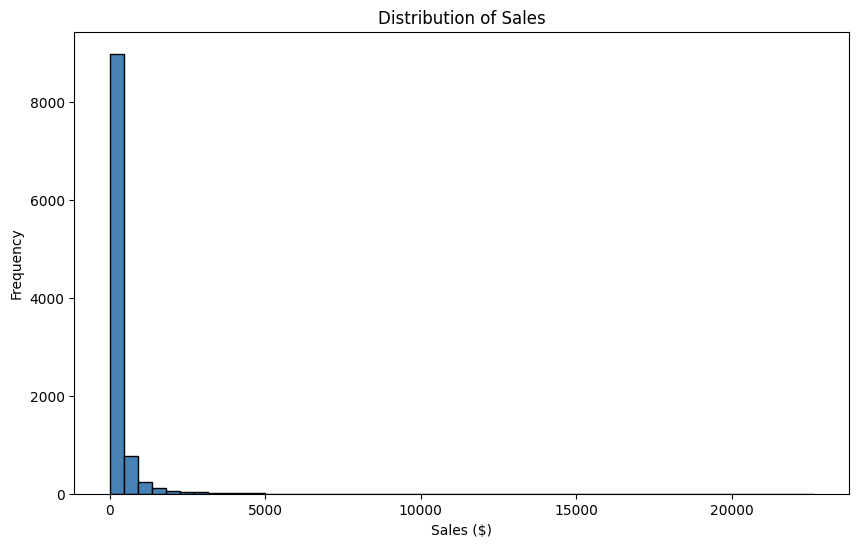

In [19]:
# Create the Sales histogram:
# bins = number of groups in histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

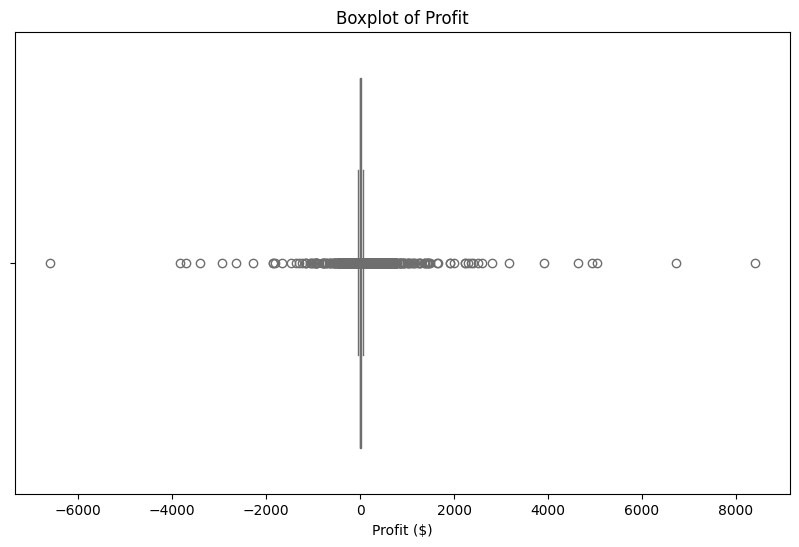

In [20]:
# Create the Profit boxplot:
# sns.boxplot() - a function in the seaborn library that draws a boxplot
# x=df['Profit'] - df is the dataset, and 'Profit' is the column being visualized
# sns.boxplot(): creates a boxplot to visualize the distribution of data and detect outliers
# x=df['Profit']: specifies that the Profit column from the dataset is used for the plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='lightcoral')
plt.title('Boxplot of Profit')
plt.xlabel('Profit ($)')
plt.show()

<Axes: xlabel='Profit'>

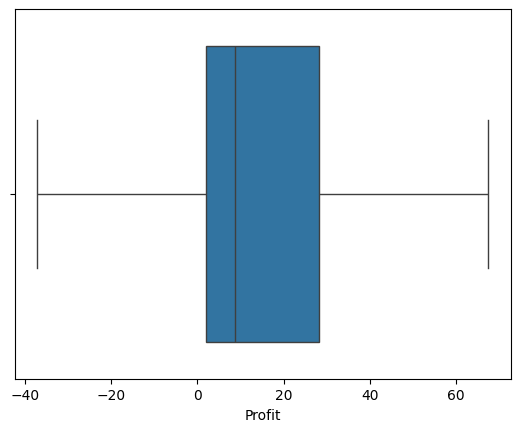

In [21]:
# showfliers=False - hides outliers from the plot
sns.boxplot(x=df['Profit'], showfliers=False)

In [22]:
# Calculate Q1, Q3, and IQR:
Q2 = df['Profit'].median()
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3- Q1
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, Q2: {Q2:.2f}, IQR: {IQR:.2f}")

Q1: 1.90, Q3: 28.17, Q2: 8.67, IQR: 26.27


The Sales distribution is right-skewed, meaning there are many small sales and a few larger ones, which is typical for retail data. This can indicate that most transactions are for lower amounts, while a smaller number of transactions involve high-value purchases.

The median value of the box plot is 8.67, meaning that 50% of the data lies below this value.

From the box plot, we can see that there are outliers extending beyond -6000 and +8000.

The first quartile (Q1) is 1.9, which means that 25% of the data is less than or equal to this value.

The third quartile (Q3) is 28.17, meaning that 75% of the data is less than or equal to this value.

In [23]:
# Calculate totals by category:
# df.groupby('Category') - groups the datafrmae by category
# It calculates the total Sales for each Region and sorts them in descending order (from the largest value to the smallest
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

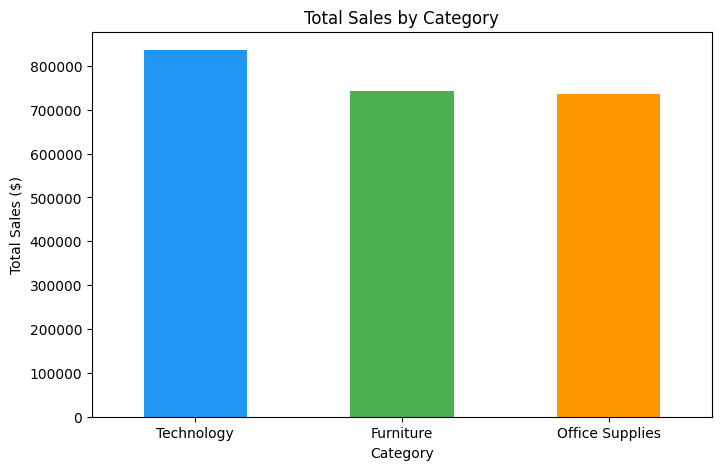

In [24]:
# Plot the bar chart:
# rotation = 0 → Furniture, Technology (written normally)
# rotation = 45 → labels appear slanted
# rotation = 90 → labels appear vertical
# cat_sales.plot(...) - plot() draws a graph based on sales by category
plt.figure(figsize=(8, 5))
cat_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

Region
West       741913.8045
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


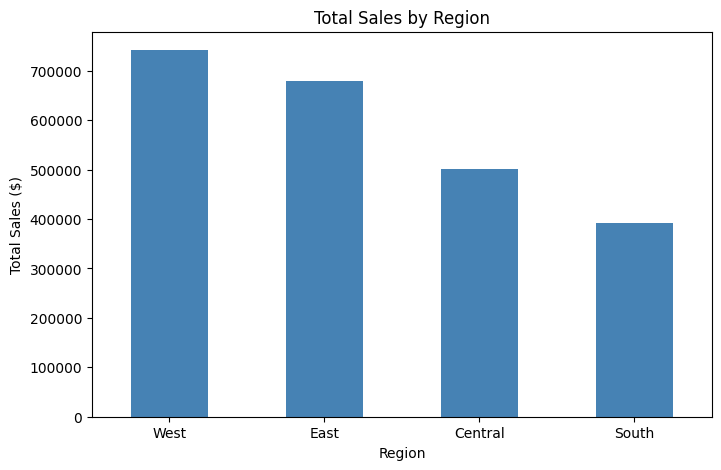

In [25]:
#Repeat for Region:
# 1 inch = 2.54 cm
# plt.figure(figsize=(8, 5)) - creates a canvas for the graph (8 = width, 5 = height)
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)
plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.show()

The Technology category produced the highest revenue. In terms of regions, the West region led in revenue generation, followed by the East region.


In [26]:
#Calculate Q1, Q3, and IQR:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3- Q1
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")

Q1: 1.90, Q3: 28.17, IQR: 26.27


In [27]:
#Determine outlier boundaries:
lower_bound = Q1- 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

Lower bound: -37.50, Upper bound: 67.58


In [28]:
# Count outliers:
# len(outliers) - number of outliers (how many anomalous values were found)
# len(df) - total number of rows in the dataset
# len(outliers) / len(df)- proportion of outliers (share of outliers in the dataset)
# 4. :.2% - this format: converts the result into a percentage and displays it with 2 decimal places
# Example:
# 0.0345 → 3.45%
outliers = df[(df['Profit'] < lower_bound) | (df['Profit'] > upper_bound)]
print(f"Number of outliers: {len(outliers)} out of {len(df)} rows ({len(outliers)/len(df):.2%})")

Number of outliers: 1966 out of 10296 rows (19.09%)


In [29]:
print("Lower outliers:", len(df[df['Profit'] < lower_bound]))
print("Upper outliers:", len(df[df['Profit'] > upper_bound]))

Lower outliers: 617
Upper outliers: 1349


Q1: 1.90  - 25% of profit ≤ 1.90

Q3: 28.17  - 75% of profit ≤ 28.17

It means most of the orders gives small profit while only small number of orders gives high profit.

The lower bound is -37.50 and the upper bound is 67.58; any values outside this range are considered outliers.

There are a total of 1,966 outliers out of 10,296 rows (19.09%). Among them, 1,349 are upper outliers (high-profit values), while 617 are lower outliers (low-profit or loss values).

In conclusion, Profit has a right-skewed distribution, meaning most orders generate small profits, while a small number of orders generate very high profits.

In [30]:
#Select numerical columns and compute correlations:
# numerical_cols → only numeric columns
# .corr() → calculates correlation between variables
# corr_matrix → the resulting correlation matrix (table)
numerical_cols = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = numerical_cols.corr()
print(corr_matrix)

             Sales  Quantity  Discount    Profit
Sales     1.000000  1.000000 -0.029887  0.479161
Quantity  1.000000  1.000000 -0.029887  0.479161
Discount -0.029887 -0.029887  1.000000 -0.219850
Profit    0.479161  0.479161 -0.219850  1.000000


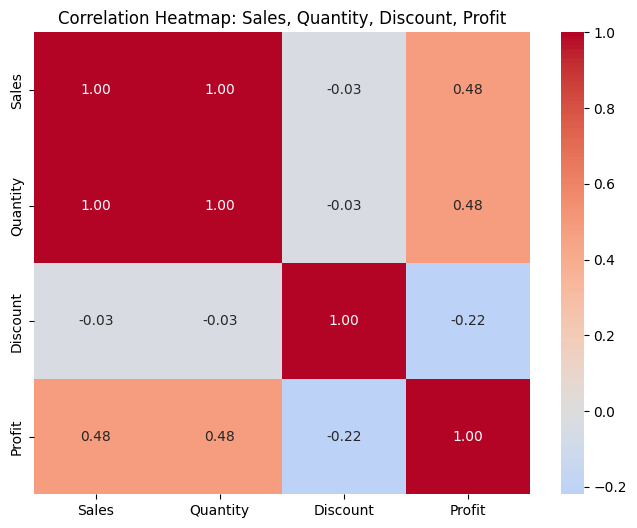

In [31]:
#Plot the heatmap:
# annot=True - shows numbers in each cell
# cmap='coolwarm' - blue indicates negative correlation, red indicates positive correlation
# center=0 - sets the midpoint of the colormap at 0
# fmt='.2f' - rounds values to 2 decimal places
# fmt = format
# 2f - f = float
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.show()

There is a strong positive correlation between Sales and Profit, and between Quantity and Profit. This suggests that if we increase sales or quantity, profit also increases.

There is a weak negative correlation between Sales and Discount, and between Quantity and Discount (-0.03). However, there is a stronger negative correlation between Discount and Profit (-0.22) compared to the relationships between Sales and Discount and between Quantity and Discount. This suggests that increasing discounts leads to a decrease in profit, meaning they are negatively related.

In [32]:
#Resample data to monthly totals:
# df.resample('M', on='Order Date')
# Order Date - uses as a time series
#'M' - Monthly
# ['Sales'].sum() - takes sales column and then adds
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

/tmp/ipykernel_3552/1766092735.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


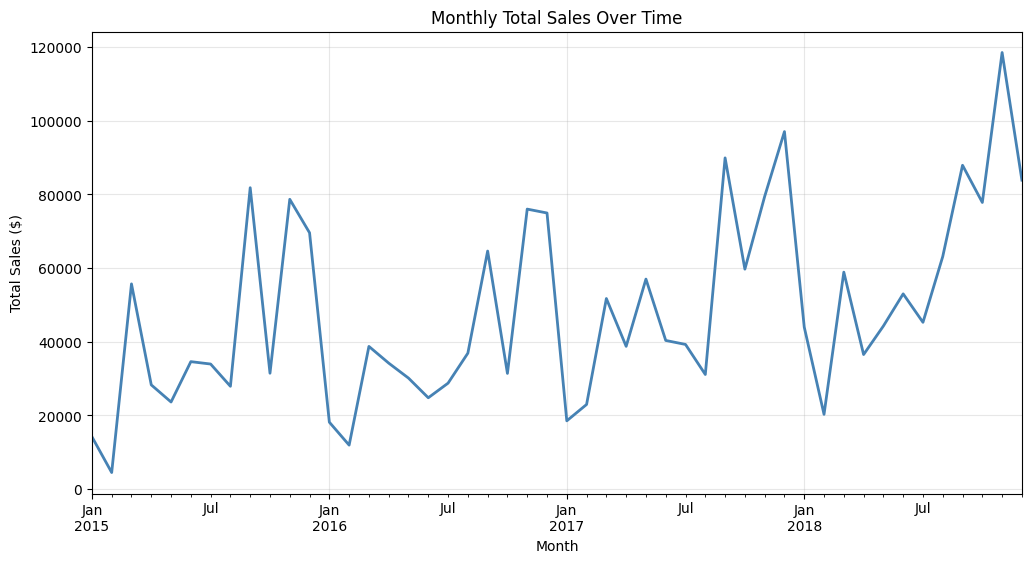

In [33]:
# Plot the line chart:
# linewidth - controls the width of the line
# plt.grid - adds grid lines to the graph
# True - turns the grid on
# alpha=0.3 - sets the transparency (lightness) of the grid lines
plt.figure(figsize=(12, 6))
monthly_sales.plot(color='steelblue', linewidth=2)
plt.title('Monthly Total Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)
plt.show()

I noticed that sales usually increase toward the end of the year, suggesting that these products are in higher demand during that period. This pattern can be described as seasonal growth.

After the year-end peak, sales drop sharply and reach their lowest point in February. They then continue to fluctuate, following a pattern of rising and falling until reaching another peak at the end of the year.

***Questions and Answers***

1. **The Sales histogram is likely right-skewed. Why does this happen in retail data?**
Because most sales occur at lower amounts, while high-value sales are relatively rare. This results in many small transactions and only a few large ones.

2. **You found outliers in Profit. Should you remove them? What information might you lose?**
I would not remove them. Outliers can provide valuable insights, such as identifying which products or categories generate exceptionally high profits. Removing them could result in losing important business insights.

3. **If Discount and Profit have a negative correlation, does that mean the company should stop giving discounts?**
No, correlation does not imply causation. Although there is a negative relationship, the correlation is relatively weak (-0.22). Discounts may still be useful for increasing sales volume, attracting customers, or clearing inventory.

4. **Looking at your monthly sales trend — if you were a store manager, what action would you take based on this chart?**
I would optimize labor and inventory levels during peak months such as November, December, and January. For seasonal products (e.g., New Year or Halloween items), I would increase stock and staffing during high-demand periods to maximize sales.